In [8]:
import pandas as pd

# Učitavanje dataseta
df = pd.read_csv('archive/GCB2022v27_MtCO2_flat.csv')

# Provera da li je učitano
print(df.shape)  # broj redova i kolona
print(df.head())  # prvih 5 redova

(63104, 11)
       Country ISO 3166-1 alpha-3  Year  Total  Coal  Oil  Gas  Cement  \
0  Afghanistan                AFG  1750    0.0   NaN  NaN  NaN     NaN   
1  Afghanistan                AFG  1751    0.0   NaN  NaN  NaN     NaN   
2  Afghanistan                AFG  1752    0.0   NaN  NaN  NaN     NaN   
3  Afghanistan                AFG  1753    0.0   NaN  NaN  NaN     NaN   
4  Afghanistan                AFG  1754    0.0   NaN  NaN  NaN     NaN   

   Flaring  Other  Per Capita  
0      NaN    NaN         NaN  
1      NaN    NaN         NaN  
2      NaN    NaN         NaN  
3      NaN    NaN         NaN  
4      NaN    NaN         NaN  


In [9]:
#Deskriptivna statistika
df.describe()


,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
count,63104.000000,62904.000000,21744.000000,21717.000000,21618.000000,20814.000000,21550.000000,1620.000000,18974.000000
mean,1885.500000,55.224788,73.968916,55.760624,23.504285,4.330443,1.712695,10.951389,4.413363
std,78.519728,824.845435,598.986992,519.034563,247.674772,50.305770,16.727067,39.034073,17.432815
min,1750.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1817.750000,0.000000,0.000000,0.091600,0.000000,0.000000,0.000000,0.520885,0.197866
50%,1885.500000,0.000000,0.271852,1.044240,0.000000,0.022756,0.000000,1.255329,1.303949
75%,1953.250000,0.549342,6.736411,8.339752,0.581628,0.568502,0.000000,4.385471,5.077994
max,2021.000000,37123.850352,15051.512770,12345.653374,7921.829472,1672.592372,439.253991,306.638573,834.192642


In [10]:
#Osnovne informacije o datasetu
df.info()
df.shape


<class 'pandas.DataFrame'>
RangeIndex: 63104 entries, 0 to 63103
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             63104 non-null  str    
 1   ISO 3166-1 alpha-3  61472 non-null  str    
 2   Year                63104 non-null  int64  
 3   Total               62904 non-null  float64
 4   Coal                21744 non-null  float64
 5   Oil                 21717 non-null  float64
 6   Gas                 21618 non-null  float64
 7   Cement              20814 non-null  float64
 8   Flaring             21550 non-null  float64
 9   Other               1620 non-null   float64
 10  Per Capita          18974 non-null  float64
dtypes: float64(8), int64(1), str(2)
memory usage: 5.3 MB


(63104, 11)

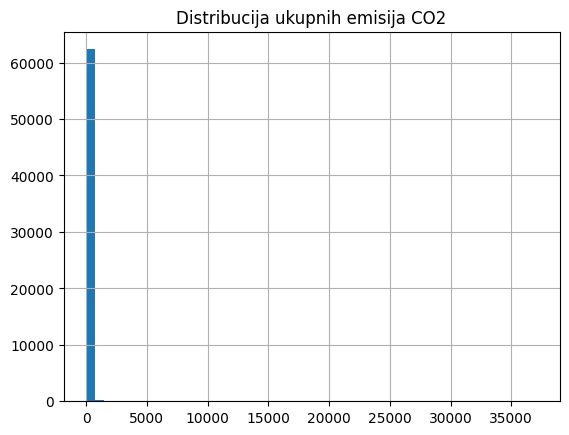

In [11]:

import matplotlib.pyplot as plt

df['Total'].hist(bins=50)
plt.title('Distribucija ukupnih emisija CO2')
plt.show()

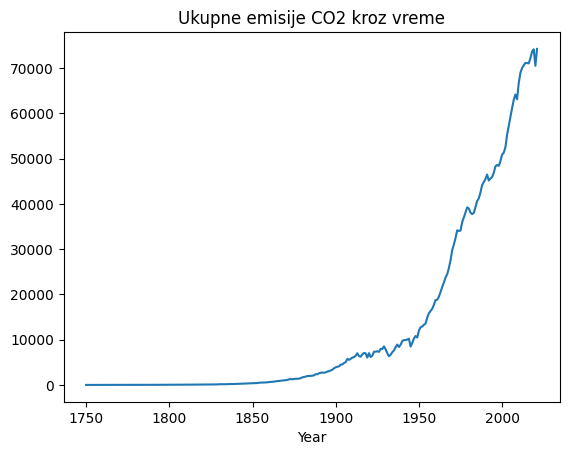

In [12]:
godisnje = df.groupby('Year')['Total'].sum()
godisnje.plot()
plt.title('Ukupne emisije CO2 kroz vreme')
plt.show()

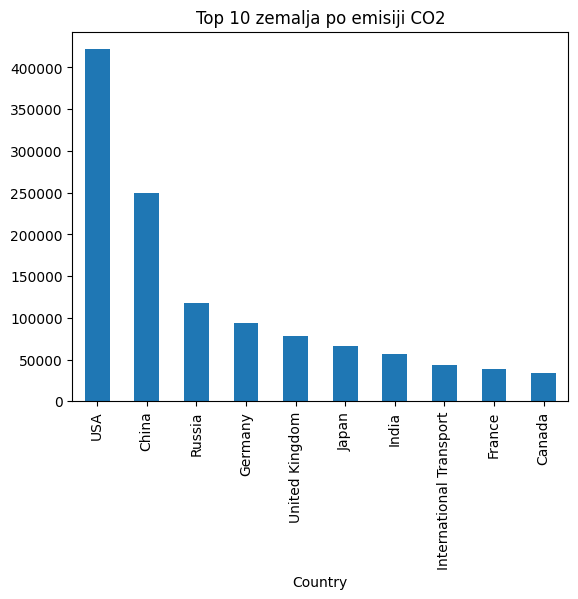

In [13]:
top10 = df[df['Country'] != 'Global'].groupby('Country')['Total'].sum().sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.title('Top 10 zemalja po emisiji CO2')
plt.show()


In [14]:
# Broj nedostajućih vrednosti po kolonama
print(df.isnull().sum())

Country                   0
ISO 3166-1 alpha-3     1632
Year                      0
Total                   200
Coal                  41360
Oil                   41387
Gas                   41486
Cement                42290
Flaring               41554
Other                 61484
Per Capita            44130
dtype: int64


In [15]:
print(f"Ukupno redova: {len(df)}")
print(f"Redova bez nedostajućih vrednosti: {df.dropna().shape[0]}")
print(f"Procenat koji ostaje: {df.dropna().shape[0]/len(df)*100:.1f}%")

Ukupno redova: 63104
Redova bez nedostajućih vrednosti: 1619
Procenat koji ostaje: 2.6%


In [16]:

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']

df_clean = df.copy()


df_clean['ISO 3166-1 alpha-3'] = df_clean['ISO 3166-1 alpha-3'].fillna('Unknown')


for kolona in numeričke:
    df_clean[kolona] = df_clean.groupby('Country')[kolona].transform(
        lambda x: x.fillna(x.median())
    )


for kolona in numeričke:
    df_clean[kolona] = df_clean[kolona].fillna(df_clean[kolona].median())


print("Nedostajuće vrednosti nakon čišćenja:")
print(df_clean.isnull().sum())

Nedostajuće vrednosti nakon čišćenja:
Country               0
ISO 3166-1 alpha-3    0
Year                  0
Total                 0
Coal                  0
Oil                   0
Gas                   0
Cement                0
Flaring               0
Other                 0
Per Capita            0
dtype: int64


In [17]:
#Test raspodele 
from scipy import stats

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']

print("=" * 55)
print(f"{'Kolona':<15} {'p-vrednost':<15} {'Raspodela'}")
print("=" * 55)

for kolona in numeričke:
    podaci = df_clean[kolona].dropna()
    uzorak = podaci.sample(min(5000, len(podaci)), random_state=42)
    stat, p = stats.shapiro(uzorak)
    
    if p > 0.05:
        raspodela = " Normalna"
    else:
        raspodela = " Nije normalna"
    
    print(f"{kolona:<15} {p:<15.6f} {raspodela}")

print("=" * 55)

Kolona          p-vrednost      Raspodela
Total           0.000000         Nije normalna
Coal            0.000000         Nije normalna
Oil             0.000000         Nije normalna
Gas             0.000000         Nije normalna
Cement          0.000000         Nije normalna
Flaring         0.000000         Nije normalna
Other           0.000000         Nije normalna
Per Capita      0.000000         Nije normalna


In [18]:
#Outlieri
numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']

for kolona in numeričke:
    Q1 = df_clean[kolona].quantile(0.25)
    Q3 = df_clean[kolona].quantile(0.75)
    IQR = Q3 - Q1
    outlieri = df_clean[(df_clean[kolona] < Q1 - 1.5 * IQR) | (df_clean[kolona] > Q3 + 1.5 * IQR)]
    print(f"{kolona}: {len(outlieri)} outliera ({len(outlieri)/len(df_clean)*100:.1f}%)")

Total: 13570 outliera (21.5%)
Coal: 11881 outliera (18.8%)
Oil: 9528 outliera (15.1%)
Gas: 14437 outliera (22.9%)
Cement: 9438 outliera (15.0%)
Flaring: 8562 outliera (13.6%)
Other: 12544 outliera (19.9%)
Per Capita: 5184 outliera (8.2%)


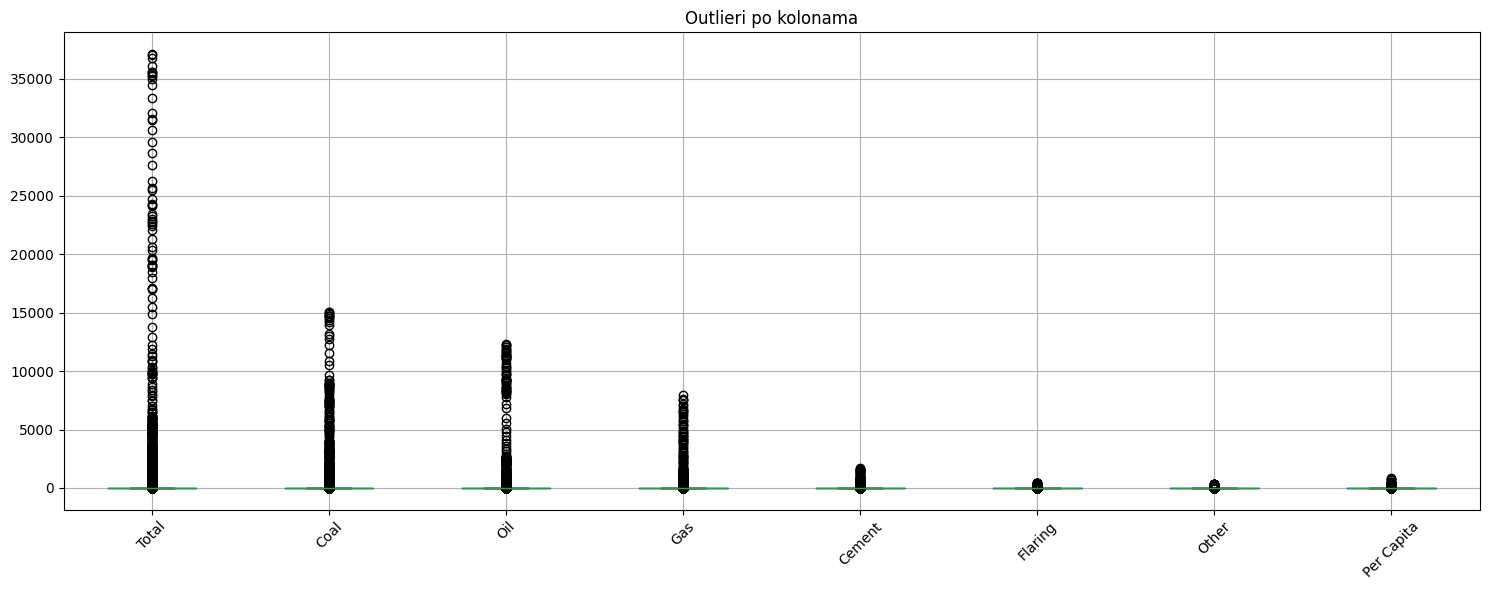

In [19]:
#Ispitivanje outliera 
import matplotlib.pyplot as plt


numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']

plt.figure(figsize=(15, 6))
df[numeričke].boxplot()
plt.title('Outlieri po kolonama')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [20]:
import numpy as np

df_clean_outlieri = df_clean.copy()

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']


for kolona in numeričke:
    p01 = df_clean_outlieri[kolona].quantile(0.01)
    p99 = df_clean_outlieri[kolona].quantile(0.99)
    df_clean_outlieri[kolona] = df_clean_outlieri[kolona].clip(lower=p01, upper=p99)


print("Outlieri nakon Winsorization:")
for kolona in numeričke:
    Q1 = df_clean_outlieri[kolona].quantile(0.25)
    Q3 = df_clean_outlieri[kolona].quantile(0.75)
    IQR = Q3 - Q1
    outlieri = df_clean_outlieri[
        (df_clean_outlieri[kolona] < Q1 - 1.5 * IQR) | 
        (df_clean_outlieri[kolona] > Q3 + 1.5 * IQR)
    ]
    print(f"{kolona}: {len(outlieri)} outliera ({len(outlieri)/len(df_clean_outlieri)*100:.1f}%)")

Outlieri nakon Winsorization:
Total: 13570 outliera (21.5%)
Coal: 11881 outliera (18.8%)
Oil: 9528 outliera (15.1%)
Gas: 14437 outliera (22.9%)
Cement: 9438 outliera (15.0%)
Flaring: 8562 outliera (13.6%)
Other: 12544 outliera (19.9%)
Per Capita: 5184 outliera (8.2%)


In [21]:
# Provera
print("Pre clip-a (df_clean):")
print(df_clean[numeričke].max())

print("\nNakon clip-a (df_clean_outlieri):")
print(df_clean_outlieri[numeričke].max())


Pre clip-a (df_clean):
Total         37123.850352
Coal          15051.512770
Oil           12345.653374
Gas            7921.829472
Cement         1672.592372
Flaring         439.253991
Other           306.638573
Per Capita      834.192642
dtype: float64

Nakon clip-a (df_clean_outlieri):
Total         610.944746
Coal          469.765473
Oil           473.445385
Gas           118.974866
Cement         25.363937
Flaring        26.820480
Other          16.101698
Per Capita     31.167550
dtype: float64


In [22]:
from sklearn.preprocessing import RobustScaler

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']

scaler = RobustScaler()

df_scaled = df_clean_outlieri.copy()
df_scaled[numeričke] = scaler.fit_transform(df_clean_outlieri[numeričke])

print("Pre skaliranja - srednja vrednost i std:")
print(df_clean_outlieri[numeričke].describe().round(2))

print("\nNakon skaliranja:")
print(df_scaled[numeričke].describe().round(2))

Pre skaliranja - srednja vrednost i std:
          Total      Coal       Oil       Gas    Cement   Flaring     Other  \
count  63104.00  63104.00  63104.00  63104.00  63104.00  63104.00  63104.00   
mean      19.71     12.87     14.63      3.10      1.20      0.61      1.52   
std       85.06     59.74     62.23     14.79      3.72      3.24      2.05   
min        0.00      0.00      0.00      0.00      0.00      0.00      0.00   
25%        0.00      0.00      0.18      0.00      0.00      0.00      1.13   
50%        0.00      0.00      0.93      0.00      0.07      0.00      1.13   
75%        0.58      1.36      4.08      0.02      0.53      0.00      1.13   
max      610.94    469.77    473.45    118.97     25.36     26.82     16.10   

       Per Capita  
count    63104.00  
mean         3.46  
std          5.52  
min          0.00  
25%          0.19  
50%          1.26  
75%          4.37  
max         31.17  

Nakon skaliranja:
          Total      Coal       Oil       Gas   

In [23]:
import pandas as pd

maddison = pd.read_excel('archive/mpd2020.xlsx', sheet_name='Full data')

print(maddison.shape)
print(maddison.head())
print(maddison.dtypes)


(21682, 5)
  countrycode      country  year   gdppc     pop
0         AFG  Afghanistan  1820     NaN  3280.0
1         AFG  Afghanistan  1870     NaN  4207.0
2         AFG  Afghanistan  1913     NaN  5730.0
3         AFG  Afghanistan  1950  1156.0  8150.0
4         AFG  Afghanistan  1951  1170.0  8284.0
countrycode        str
country            str
year             int64
gdppc          float64
pop            float64
dtype: object


In [24]:
print(maddison.shape)         # broj redova i kolona
print(maddison.isnull().sum()) # nedostajuce vrednosti po kolonama
print(maddison['year'].min(), maddison['year'].max())  # opseg godina



(21682, 5)
countrycode       0
country           0
year              0
gdppc          1976
pop            4483
dtype: int64
1 2018


In [25]:
maddison_1925 = maddison[maddison['year'] >= 1925]

print(maddison_1925.shape)
print(maddison_1925.isnull().sum())
print(maddison_1925['country'].nunique())


(13306, 5)
countrycode      0
country          0
year             0
gdppc          809
pop             45
dtype: int64
169


In [26]:
#filtriramo glavni dataset na 1925+
df_1925 = df[df['Year'] >= 1925].copy()

#spajanje
df_merged = df_1925.merge(
    maddison_1925[['countrycode', 'year', 'gdppc', 'pop']],
    left_on=['ISO 3166-1 alpha-3', 'Year'],
    right_on=['countrycode', 'year'],
    how='left'
)

#uklonimo duplikat kolone
df_merged = df_merged.drop(columns=['countrycode', 'year'])

print(df_merged.shape)
print(df_merged[['Country', 'Year', 'Total', 'gdppc', 'pop']].head(10))
print(df_merged[['gdppc', 'pop']].isnull().sum())


(22504, 13)
       Country  Year  Total  gdppc  pop
0  Afghanistan  1925    0.0    NaN  NaN
1  Afghanistan  1926    0.0    NaN  NaN
2  Afghanistan  1927    0.0    NaN  NaN
3  Afghanistan  1928    0.0    NaN  NaN
4  Afghanistan  1929    0.0    NaN  NaN
5  Afghanistan  1930    0.0    NaN  NaN
6  Afghanistan  1931    0.0    NaN  NaN
7  Afghanistan  1932    0.0    NaN  NaN
8  Afghanistan  1933    0.0    NaN  NaN
9  Afghanistan  1934    0.0    NaN  NaN
gdppc    10267
pop       9514
dtype: int64


In [ ]:
print(df_merged.shape) #gledamo kolko redova i kolona ima spojeni dataset
print(df_merged[['Country', 'Year', 'Total', 'gdppc', 'pop']].head(10))
#to gore prikazuje prvih 10 redova sa tim kolonama
print(df_merged[['gdppc', 'pop']].isnull().sum())
#kolko naan vr ima u novim kolonama tj koje se nisu spojile


(22504, 13)
       Country  Year  Total  gdppc  pop
0  Afghanistan  1925    0.0    NaN  NaN
1  Afghanistan  1926    0.0    NaN  NaN
2  Afghanistan  1927    0.0    NaN  NaN
3  Afghanistan  1928    0.0    NaN  NaN
4  Afghanistan  1929    0.0    NaN  NaN
5  Afghanistan  1930    0.0    NaN  NaN
6  Afghanistan  1931    0.0    NaN  NaN
7  Afghanistan  1932    0.0    NaN  NaN
8  Afghanistan  1933    0.0    NaN  NaN
9  Afghanistan  1934    0.0    NaN  NaN
gdppc    10267
pop       9514
dtype: int64


In [30]:
# Koje godine Maddison ima za Avganistan?
print(maddison[maddison['countrycode'] == 'AFG']['year'].values)



# Koliko drzava uopste nije spojeno?
nije_spojeno = df_merged[df_merged['pop'].isnull()]['Country'].unique()
print(f"Broj drzava bez pop podataka: {len(nije_spojeno)}")
print(nije_spojeno[:20])


[1820 1870 1913 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960
 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974
 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988
 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018]
Broj drzava bez pop podataka: 232
<StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
             'Andorra',              'Angola',            'Anguilla',
          'Antarctica', 'Antigua and Barbuda',           'Argentina',
             'Armenia',               'Aruba',           'Australia',
             'Austria',          'Azerbaijan',             'Bahamas',
             'Bahrain',          'Bangladesh',            'Barbados',
             'Belarus',             'Belgium']
Length: 20, dtype: str


In [31]:
# Koje drzave su potpuno odsutne iz Maddisona (ni jedna godina se nije spojila)
maddison_kodovi = set(maddison['countrycode'].unique())
glavni_kodovi = df_merged[['Country', 'ISO 3166-1 alpha-3']].drop_duplicates()

odsutne = glavni_kodovi[~glavni_kodovi['ISO 3166-1 alpha-3'].isin(maddison_kodovi)]
print(f"Potpuno odsutne drzave: {len(odsutne)}")
print(odsutne.to_string())


Potpuno odsutne drzave: 66
                                 Country ISO 3166-1 alpha-3
291                              Andorra                AND
485                             Anguilla                AIA
582                           Antarctica                ATA
679                  Antigua and Barbuda                ATG
970                                Aruba                ABW
1358                             Bahamas                BHS
1940                              Belize                BLZ
2134                             Bermuda                BMU
2231                              Bhutan                BTN
2328   Bonaire, Saint Eustatius and Saba                BES
2716              British Virgin Islands                VGB
2813                   Brunei Darussalam                BRN
3880                    Christmas Island                CXR
4268                        Cook Islands                COK
4753                             Curaçao                CUW
6014         

In [27]:

pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
